# Module 03 — the laboratory scoreboard: matrix and gas-phase infrared bands of PAHs

**These are laboratory measurements from the public PAHdb experimental library and the NIST Chemistry WebBook. Not synthetic, not AI-generated, not the Module 02 dataset.**

Plan 05 (Δ-probed IR pipeline), Module 03 of the Udacity AI Mastery Capstone. The dataset is `bands_lab.csv` in this folder: one row per laboratory band — every band of the 84 species of NASA's PAHdb *experimental* library v3.10 (argon-matrix spectra), the peaks of eight gas-phase NIST WebBook records for six PAHs, and the four benzene bands of the project's R0 scoreboard. The second file, `pairs_matrix_gas.csv`, holds the matrix–gas pairs formed under the rule frozen in `../PRE_REGISTRATION.md` **before** any pair was computed. The analytical question is that note's question: **is the offset between a band's matrix position and its gas-phase position zero, per band family?**

Sections: **Load · Descriptive statistics · Visual models · Hypothesis test · Summary**.

## Load the dataset

In [1]:
from pathlib import Path
import json
import numpy as np, pandas as pd
import scipy, scipy.stats as st
%matplotlib inline
import matplotlib.pyplot as plt
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)
DATA = Path("bands_lab.csv"); PAIRS = Path("pairs_matrix_gas.csv"); FIG = Path("figures"); FIG.mkdir(exist_ok=True)
df = pd.read_csv(DATA); pairs = pd.read_csv(PAIRS)
print("pandas", pd.__version__, "| numpy", np.__version__, "| scipy", scipy.__version__)
print("dataset:", df.shape, "| pairs:", pairs.shape)
df.head()

pandas 3.0.3 | numpy 2.5.1 | scipy 1.18.1
dataset: (4218, 21) | pairs: (74, 14)


,band_id,phase,source,record,species,formula,charge,n_c,uid,temperature_K,resolution_cm,frequency_cm,intensity,intensity_unit,snr,fwhm_cm,u_c_cm,u_res_cm,source_ref,role,family
0,1,matrix,PAHdb experimental 3.10 (Ar matrix),uid 330,naphthalene,C10H8,0,10,330.0,10.0,0.9,473.7,18.6690,relative (PAHdb experimental),NaN,NaN,NaN,0.9,10.1021/jp9834816,matrix,low / skeletal
1,2,matrix,PAHdb experimental 3.10 (Ar matrix),uid 330,naphthalene,C10H8,0,10,330.0,10.0,0.9,620.3,4.3359,relative (PAHdb experimental),NaN,NaN,NaN,0.9,10.1021/jp9834816,matrix,low / skeletal
2,3,matrix,PAHdb experimental 3.10 (Ar matrix),uid 330,naphthalene,C10H8,0,10,330.0,10.0,0.9,785.8,108.4000,relative (PAHdb experimental),NaN,NaN,NaN,0.9,10.1021/jp9834816,matrix,CH-oop (10.5-15 um; benzene nu11 at 673 included)
3,4,matrix,PAHdb experimental 3.10 (Ar matrix),uid 330,naphthalene,C10H8,0,10,330.0,10.0,0.9,957.6,3.2520,relative (PAHdb experimental),NaN,NaN,NaN,0.9,10.1021/jp9834816,matrix,ring / CH-ip (9-10.5 um)
4,5,matrix,PAHdb experimental 3.10 (Ar matrix),uid 330,naphthalene,C10H8,0,10,330.0,10.0,0.9,1014.4,7.8288,relative (PAHdb experimental),NaN,NaN,NaN,0.9,10.1021/jp9834816,matrix,ring / CH-ip (9-10.5 um)


In [2]:
print(df.dtypes.to_string())
print()
print("missing values per column:"); print(df.isna().sum()[df.isna().sum() > 0].to_string())

band_id             int64
phase                 str
source                str
record                str
species               str
formula               str
charge              int64
n_c                 int64
uid               float64
temperature_K     float64
resolution_cm     float64
frequency_cm      float64
intensity         float64
intensity_unit        str
snr               float64
fwhm_cm           float64
u_c_cm            float64
u_res_cm          float64
source_ref            str
role                  str
family                str

missing values per column:
uid               124
temperature_K    3991
resolution_cm    3712
intensity           4
snr              3896
fwhm_cm          3896
u_c_cm           3900
u_res_cm         3712
source_ref        943


*Reading the load.* Numeric columns (positions, intensities, S/N, widths, uncertainties) loaded as floats, identifiers and labels as strings. The missing values are structural, not errors: the matrix rows have no S/N, width or centroid precision because the library stores band lists, not spectra; the temperature and resolution of a matrix band are filled only for the eight species whose original paper has been read (Hudgins & Sandford, 1998: argon, 10 K, 0.9 cm⁻¹), and left empty — not guessed — for the rest. `uid` is empty for gas records of species that have no matrix entry.

## Descriptive statistics

Summary statistics of the numeric columns, counts of the categorical columns (phase, role, family, species), and the distribution of the key numeric variable, the band position, by phase.

In [3]:
df[["frequency_cm", "intensity", "snr", "fwhm_cm", "u_c_cm", "u_res_cm", "n_c"]].describe().round(2)

,frequency_cm,intensity,snr,fwhm_cm,u_c_cm,u_res_cm,n_c
count,4218.00,4214.00,322.00,322.00,318.00,506.00,4218.00
mean,1403.85,190.65,412.76,331.41,2.73,4.47,26.32
std,657.64,1917.27,2911.80,861.63,6.93,3.33,11.74
min,432.70,0.00,10.10,0.24,0.00,0.12,6.00
25%,945.30,1.39,21.52,22.19,0.13,0.90,17.00
50%,1321.50,4.58,48.00,35.78,0.32,4.00,21.00
75%,1659.42,20.08,162.78,88.05,1.52,8.00,36.00
max,5701.60,62180.00,50824.00,3342.00,58.90,8.00,50.00


In [4]:
print(df["phase"].value_counts().to_string()); print()
print(df["role"].value_counts().to_string()); print()
print(df["family"].value_counts().to_string()); print()
print("species with matrix bands:", df.loc[df.phase == "matrix", "uid"].nunique(), "PAHdb entries |", "species with gas records:", sorted(df.loc[df.phase == "gas", "species"].unique()))
print(); print(df.groupby("phase")["frequency_cm"].describe().round(1))
print(); print("gas peaks per record:"); print(df[df.phase == "gas"].groupby("record").agg(species=("species", "first"), peaks=("frequency_cm", "size"), res_cm=("u_res_cm", "first"), snr_median=("snr", "median")).to_string())

phase
matrix    3896
gas        322

role
matrix           3896
primary           159
gas only          120
secondary          39
R0 scoreboard       4

family
CC-stretch/CH-ip (7.7 um)                            892
overtone / combination region                        816
CH-oop (10.5-15 um; benzene nu11 at 673 included)    752
CH-ip-bend (8.6 um)                                  482
CC-stretch (6.2 um)                                  390
ring / CH-ip (9-10.5 um)                             321
low / skeletal                                       317
CH-stretch                                           178
above 3200                                            70

species with matrix bands: 84 PAHdb entries | species with gas records: ['anthracene', 'benzene', 'chrysene', 'naphthalene', 'pyrene', 'triphenylene']

         count    mean     std    min    25%     50%     75%     max
phase                                                               
gas      322.0  1756.5  1017.5  462.

*What the statistics reveal.* The dataset is dominated by the matrix side (3,896 of 4,218 rows); the gas side is 322 peaks from nine records. Matrix band positions run from 433 to 5,702 cm⁻¹ with a median near 1,314 cm⁻¹, i.e. in the 7.7 µm C–C/C–H region that also holds the most rows per family; gas peaks lie higher on average (median 1,596 cm⁻¹) because the hot GC-IRD spectra carry many weak features in the 1,650–2,950 cm⁻¹ overtone region that the matrix band lists do not report. The gas records differ sharply in quality: the stated resolution is 8 cm⁻¹ for the six GC-IRD records against 0.125 cm⁻¹ for the quantitative benzene cell record, and the median signal-to-noise per record ranges from about 20 to over 300. The centroid precision u_c is therefore small (median 0.17 cm⁻¹ among the primary pairs) while the resolution term is not: the resolution, not the noise, limits what these gas records can show.

## Three visual models

Figure 1 (histogram) compares where the matrix bands and the gas peaks lie. Figure 2 (boxplot) shows the matrix−gas offset Δ per band family for the primary pairs. Figure 3 (scatter) shows every pair's Δ against its gas position, by species, with the secondary naphthalene column as hollow markers.

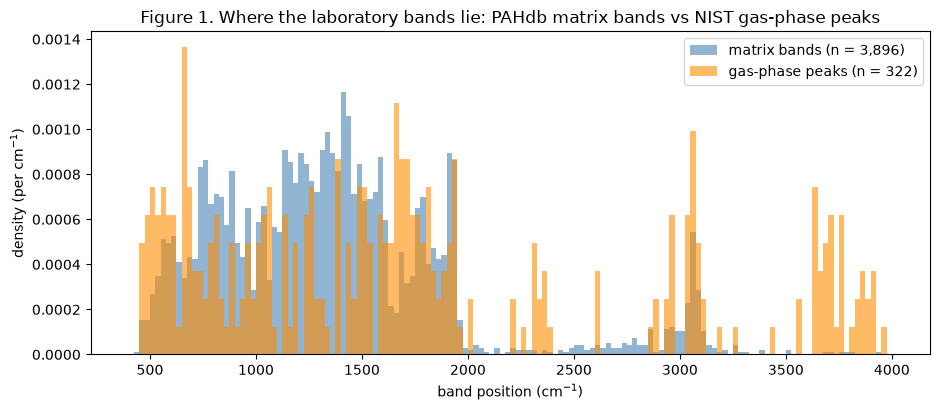

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
bins = np.arange(400, 4025, 25)
ax.hist(df.loc[df.phase == "matrix", "frequency_cm"], bins=bins, density=True, alpha=0.6, color="steelblue", label=f"matrix bands (n = {int((df.phase=='matrix').sum()):,})")
ax.hist(df.loc[df.phase == "gas", "frequency_cm"], bins=bins, density=True, alpha=0.6, color="darkorange", label=f"gas-phase peaks (n = {int((df.phase=='gas').sum())})")
ax.set_xlabel("band position (cm$^{-1}$)"); ax.set_ylabel("density (per cm$^{-1}$)")
ax.set_title("Figure 1. Where the laboratory bands lie: PAHdb matrix bands vs NIST gas-phase peaks")
ax.legend(); plt.tight_layout(); fig.savefig(FIG / "fig1_positions_by_phase.png", dpi=140); plt.show()

C:\Users\thebr\AppData\Local\Temp\ipykernel_6328\1175231164.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([prim.loc[prim.family == f, "delta_cm"].values for f in order], tick_labels=[f.split(" (")[0] for f in order], vert=True, widths=0.6)


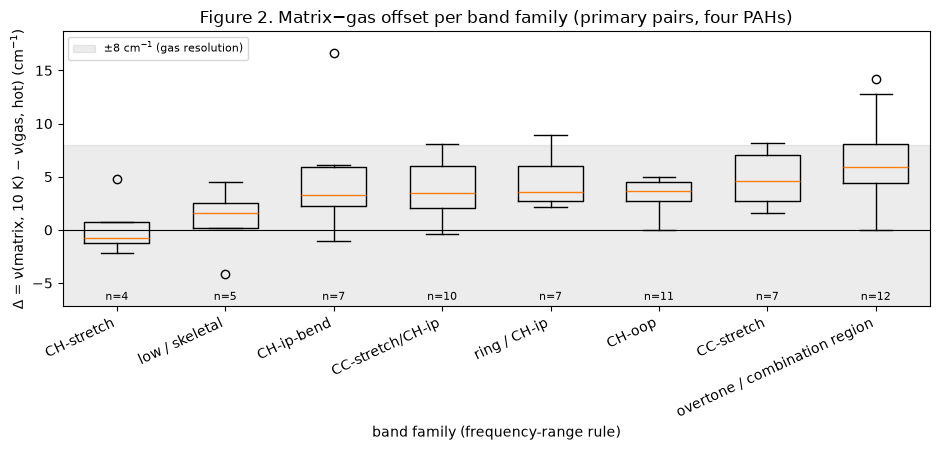

In [6]:
prim = pairs[pairs.gas_role == "primary"].copy()
order = prim.groupby("family")["delta_cm"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.boxplot([prim.loc[prim.family == f, "delta_cm"].values for f in order], tick_labels=[f.split(" (")[0] for f in order], vert=True, widths=0.6)
ax.set_ylim(prim.delta_cm.min() - 3, prim.delta_cm.max() + 2)
for i, f in enumerate(order, start=1):
    ax.text(i, prim.delta_cm.min() - 2.4, f"n={int((prim.family == f).sum())}", ha="center", fontsize=8)
ax.axhline(0, color="black", lw=0.8); ax.axhspan(-8, 8, color="grey", alpha=0.15, label="±8 cm$^{-1}$ (gas resolution)")
ax.set_xlabel("band family (frequency-range rule)"); ax.set_ylabel("Δ = ν(matrix, 10 K) − ν(gas, hot) (cm$^{-1}$)")
ax.set_title("Figure 2. Matrix−gas offset per band family (primary pairs, four PAHs)")
ax.legend(loc="upper left", fontsize=8); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); fig.savefig(FIG / "fig2_delta_by_family.png", dpi=140); plt.show()

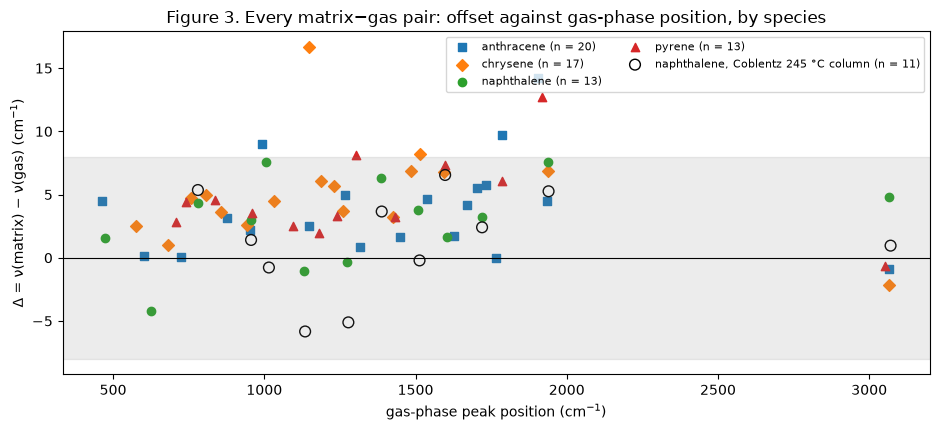

             count  median  mean   std
species                               
anthracene      20    3.66  3.92  3.74
chrysene        17    4.75  5.05  3.91
naphthalene     13    3.24  2.94  3.44
pyrene          13    3.58  4.62  3.36


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
markers = {"naphthalene": "o", "anthracene": "s", "pyrene": "^", "chrysene": "D"}
for sp, g in prim.groupby("species"):
    ax.scatter(g.nu_gas_cm, g.delta_cm, marker=markers[sp], s=36, label=f"{sp} (n = {len(g)})")
sec = pairs[pairs.gas_role == "secondary"]
ax.scatter(sec.nu_gas_cm, sec.delta_cm, marker="o", s=60, facecolors="none", edgecolors="black", label=f"naphthalene, Coblentz 245 °C column (n = {len(sec)})")
ax.axhline(0, color="black", lw=0.8); ax.axhspan(-8, 8, color="grey", alpha=0.15)
ax.set_xlabel("gas-phase peak position (cm$^{-1}$)"); ax.set_ylabel("Δ = ν(matrix) − ν(gas) (cm$^{-1}$)")
ax.set_title("Figure 3. Every matrix−gas pair: offset against gas-phase position, by species")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); fig.savefig(FIG / "fig3_delta_vs_position.png", dpi=140); plt.show()
print(prim.groupby("species")["delta_cm"].agg(["count", "median", "mean", "std"]).round(2))

*Comparing the three visual models.* Figure 1 shows the two sides cover the same spectral range and that the matrix library is far denser below 1,650 cm⁻¹, while the gas records add a tail of weak overtone features and, near 2,350 and above 3,500 cm⁻¹, peaks that are most likely residual atmospheric CO₂ and water vapour in the gas records rather than PAH bands — they have no matrix counterpart and enter no pair; the histogram says nothing about offsets, because it does not pair bands. Figure 3 pairs them: almost every point lies above zero, the offsets sit inside the ±8 cm⁻¹ band of the gas resolution, no species stands apart, and the 245 °C Coblentz column of naphthalene (hollow circles) scatters around the same values as the GC-IRD column. Figure 2 is the model that answers the analytical question, because the question is asked *per family*: it shows the median offset by family, its spread, and how many pairs each family has — the two families with fewer than six pairs are visible at once as the ones the pre-registered rule will not test. The trade-off is that Figure 2 hides the species and the position inside each family, which Figure 3 keeps.

## Hypothesis test (pre-registered on 2026-09-11, before the join)

**H₀ (per family):** the distribution of the offsets Δ = ν_matrix − ν_gas is symmetric about 0 (median offset zero).
**H₁:** it is not (two-sided).

Test: Wilcoxon signed-rank on the primary pairs of each family (Wilcoxon, 1945); α = 0.05 with Holm–Bonferroni across the families tested; a family with fewer than 6 pairs is *inconclusive by construction* and is not tested; the pooled test over all primary pairs is a declared secondary result. Printed beside the test, not tested: median, mean, SD, a 95 % bootstrap interval of the median (10,000 resamples, seed 0) and the share of pairs with |Δ| ≤ 8 cm⁻¹. The form is fixed in `../PRE_REGISTRATION.md`; nothing here was tuned after seeing the pairs.

In [8]:
ALPHA, N_MIN = 0.05, 6
rng = np.random.default_rng(0)

def holm(p):
    """Holm–Bonferroni adjusted p-values (step-down), same order as the input."""
    p = np.asarray(p, float); m = len(p); order = np.argsort(p); adj = np.empty(m); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, min(1.0, (m - rank) * p[i])); adj[i] = run
    return adj

rows = []
for fam, g in prim.groupby("family"):
    d = g["delta_cm"].to_numpy()
    boot = [np.median(rng.choice(d, len(d))) for _ in range(10_000)]
    row = dict(family=fam, n=len(d), median=np.median(d), mean=d.mean(), sd=d.std(ddof=1), ci_low=np.percentile(boot, 2.5), ci_high=np.percentile(boot, 97.5), share_within_8=(np.abs(d) <= 8).mean())
    if len(d) < N_MIN:
        row.update(W=np.nan, p=np.nan, status="inconclusive by construction")
    else:
        w = st.wilcoxon(d, zero_method="wilcox", alternative="two-sided", method="auto")
        row.update(W=w.statistic, p=w.pvalue, status="tested")
    rows.append(row)
res = pd.DataFrame(rows)
tested = res.status == "tested"
res.loc[tested, "p_holm"] = holm(res.loc[tested, "p"])
res["decision"] = np.where(~tested, "not tested (n < 6)", np.where(res["p_holm"] <= ALPHA, "reject H0", "do not reject H0"))
pooled = st.wilcoxon(prim["delta_cm"].to_numpy(), zero_method="wilcox", alternative="two-sided", method="auto")
print(res[["family", "n", "median", "mean", "sd", "ci_low", "ci_high", "share_within_8", "W", "p", "p_holm", "decision"]].round(4).to_string(index=False))
print(f"\nsecondary (declared): pooled Wilcoxon over all {len(prim)} primary pairs — W = {pooled.statistic:.1f}, p = {pooled.pvalue:.2e}, median Δ = {prim.delta_cm.median():.2f} cm⁻¹")
sec = pairs[pairs.gas_role == "secondary"]
print(f"labelled column, not pooled: naphthalene against the 245 °C Coblentz record — n = {len(sec)}, median Δ = {sec.delta_cm.median():.2f} cm⁻¹")
json.dump({"alpha": ALPHA, "n_min": N_MIN, "per_family": res.round(6).to_dict(orient="records"), "pooled": {"n": int(len(prim)), "W": float(pooled.statistic), "p": float(pooled.pvalue), "median": float(prim.delta_cm.median())},
           "secondary_naphthalene_245C": {"n": int(len(sec)), "median": float(sec.delta_cm.median())}}, open("test_results.json", "w"), indent=1)
print("written test_results.json")

                                           family  n  median   mean     sd  ci_low  ci_high  share_within_8   W      p  p_holm           decision
                              CC-stretch (6.2 um)  7    4.64 4.8700 2.6621   1.760     7.37          0.8571 0.0 0.0156  0.0469          reject H0
                        CC-stretch/CH-ip (7.7 um) 10    3.49 3.8650 2.7160   1.680     6.34          0.9000 1.0 0.0039  0.0156          reject H0
                              CH-ip-bend (8.6 um)  7    3.30 5.0186 5.6710   1.930     6.08          0.8571 1.0 0.0312  0.0469          reject H0
CH-oop (10.5-15 um; benzene nu11 at 673 included) 11    3.64 3.2936 1.5992   2.560     4.56          1.0000 0.0 0.0010  0.0059          reject H0
                                       CH-stretch  4   -0.78 0.2700 3.1056  -2.180     4.82          1.0000 NaN    NaN     NaN not tested (n < 6)
                                   low / skeletal  5    1.57 0.9180 3.2590  -4.180     4.52          1.0000 NaN    NaN     N

## Summary

We explored 4,218 laboratory infrared bands — the whole PAHdb argon-matrix library plus the peaks of nine gas-phase NIST WebBook records — and paired the matrix and gas bands of naphthalene, anthracene, pyrene and chrysene under a rule fixed before the pairing was run, obtaining 63 primary pairs. In the six families with at least six pairs the matrix position lies systematically *above* the hot gas-phase position, by a median of 3.3 to 5.9 cm⁻¹, and the pre-registered Wilcoxon test rejects a zero offset in all six after the Holm correction (adjusted p between 0.006 and 0.047); the C–H stretch and the low-frequency family have too few pairs and are reported as inconclusive by construction. The unexpected part is the sign's consistency: with 8 cm⁻¹ gas resolution we expected the offsets to be lost in the noise, but the pairs are precise enough (median centroid precision 0.17 cm⁻¹) for a systematic shift smaller than the resolution to show, and the 245 °C naphthalene column gives the same picture. The offset mixes two physical effects, the matrix shift and the hot-band shift of the vapour, which this data cannot separate; and four molecules carry the whole result. The challenge was the join itself: the GC-IRD records report many weak hot-band features with no counterpart in the matrix lists, so 96 of 159 primary gas peaks stay unmatched, and the matching rule had to be written down before, not after, seeing which bands it would pick.